# Análisis Exploratorio de Datos (EDA)

Exploraremos los datos limpios para comprender las relaciones entre las variables de supervivenia.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/titanic_clean.csv')
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
541,0,3,female,9.0,4,2,31.2750,S
545,0,1,male,64.0,0,0,26.0000,S
85,1,3,female,33.0,3,0,15.8500,S
307,1,1,female,17.0,1,0,108.9000,C
727,1,3,female,28.0,0,0,7.7375,Q


# Supervivencia por Género

In [3]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

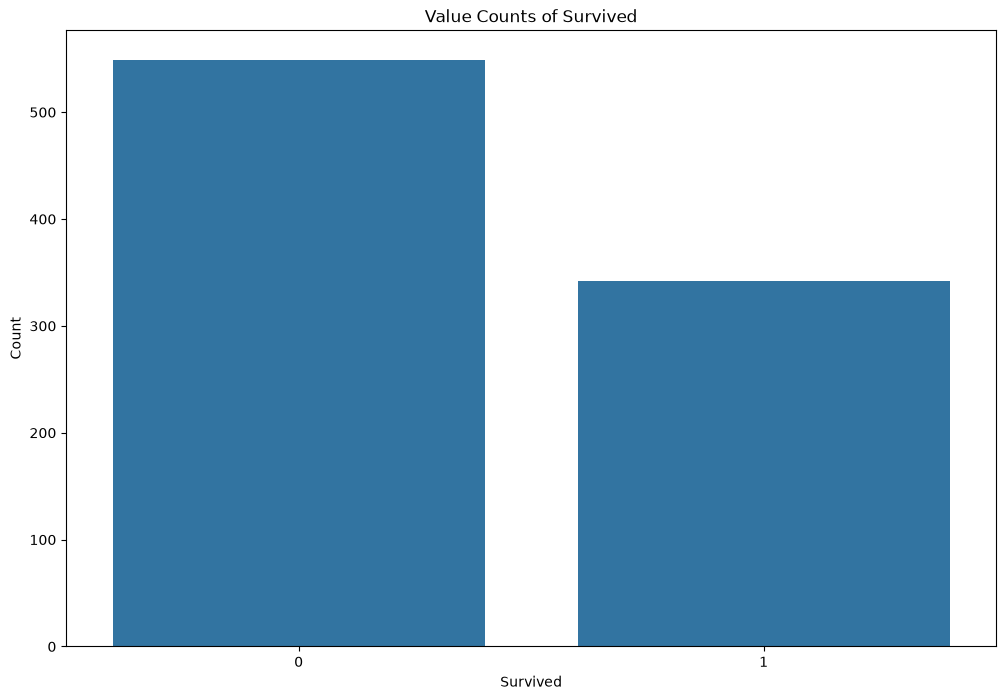

In [4]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

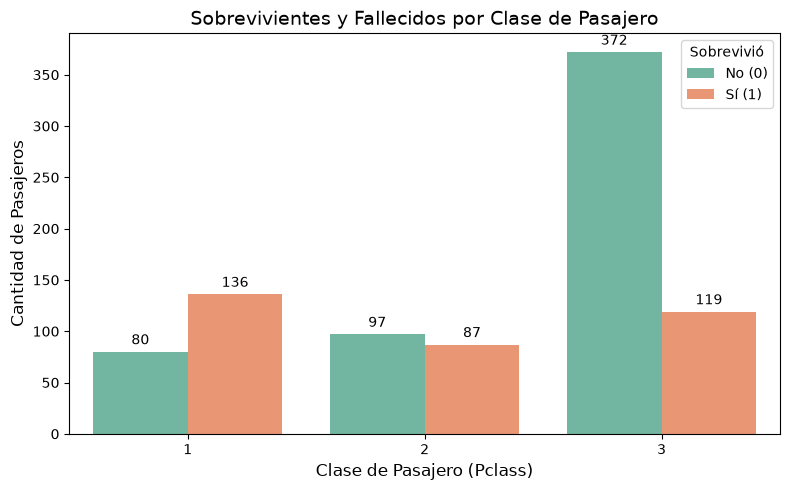

In [5]:
plt.figure(figsize=(8, 5))

# Crear el gráfico de barras comparando Pclass y Survived
ax = sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set2')

plt.title('Sobrevivientes y Fallecidos por Clase de Pasajero', fontsize=14)
plt.xlabel('Clase de Pasajero (Pclass)', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)
plt.legend(title='Sobrevivió', labels=['No (0)', 'Sí (1)'])

# Añadir las etiquetas con el número exacto sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

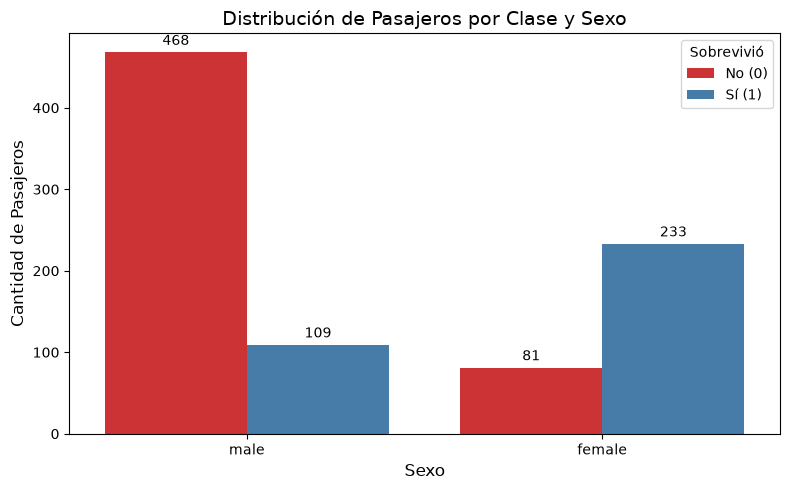

In [ ]:
plt.figure(figsize=(8, 5))

# Crear el gráfico de barras comparando Pclass y Sex
ax = sns.countplot(data=df, x='Sex', hue='Survived', palette='Set1')

plt.title('Sobrevivientes y Fallecidos por Sexo', fontsize=14)
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)
plt.legend(title='Sobrevivió', labels=['No (0)', 'Sí (1)'])

# Añadir las etiquetas con el número exacto sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

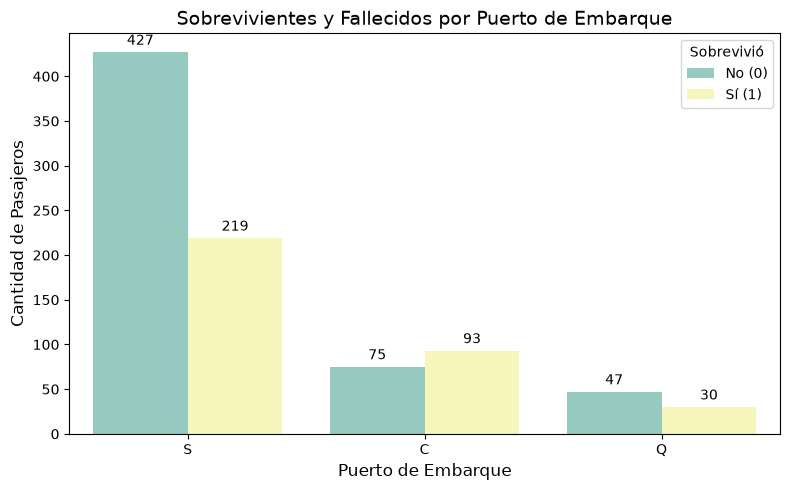

In [11]:
plt.figure(figsize=(8, 5))

# Crear el gráfico de barras comparando Survived y Embarked
ax = sns.countplot(data=df, x='Embarked', hue='Survived', palette='Set3')

plt.title('Sobrevivientes y Fallecidos por Puerto de Embarque', fontsize=14)
plt.xlabel('Puerto de Embarque', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)
plt.legend(title='Sobrevivió', labels=['No (0)', 'Sí (1)'])

# Añadir las etiquetas con el número exacto sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

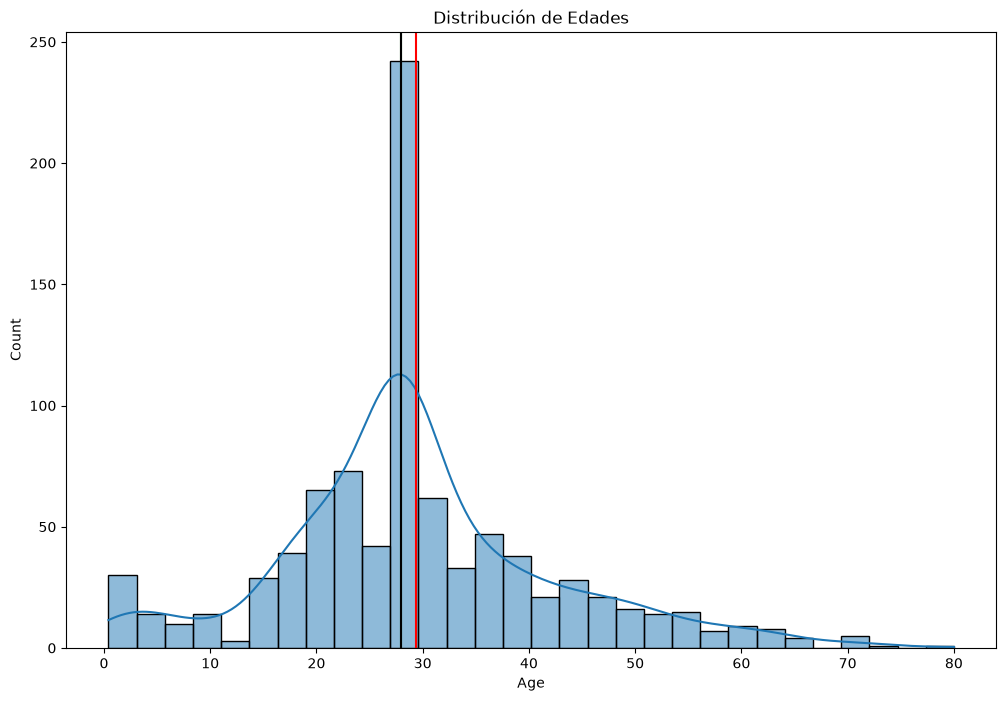

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


In [12]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

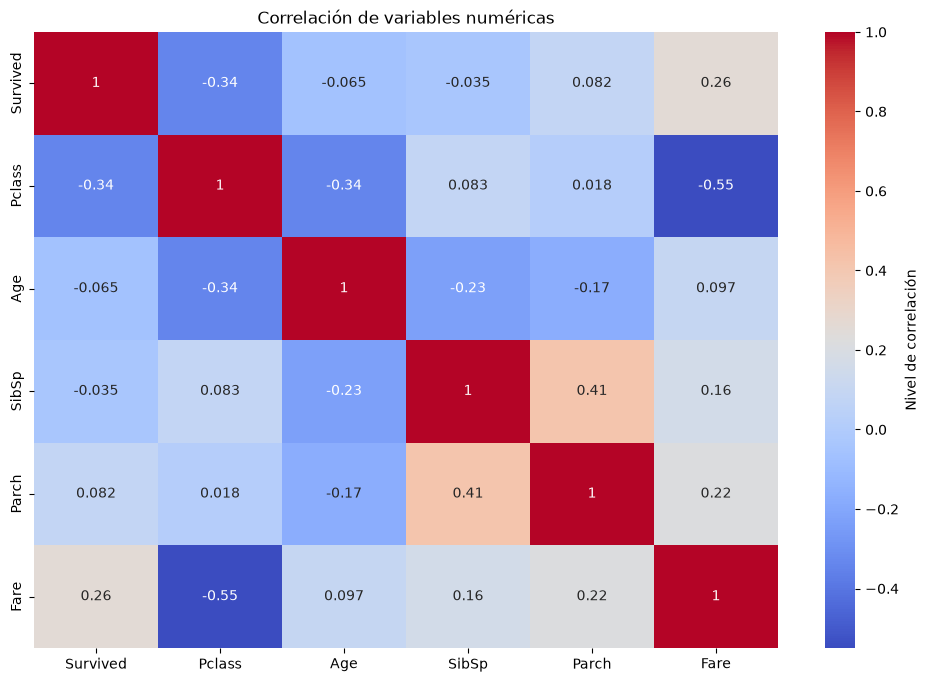

In [13]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

/tmp/ipykernel_11413/1505180528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')


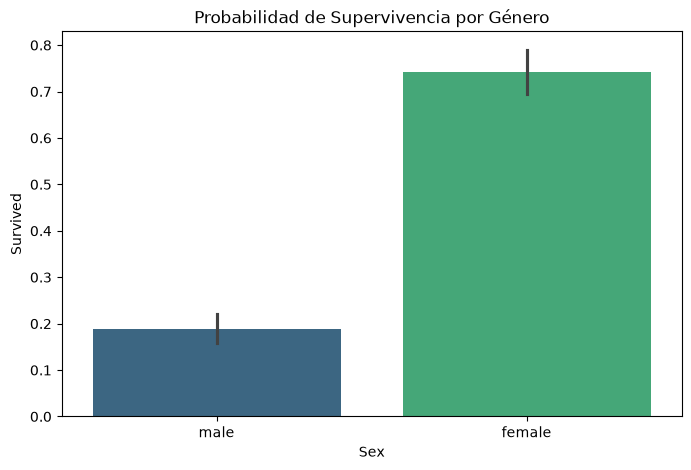

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')
plt.title('Probabilidad de Supervivencia por Género')
plt.show()

/tmp/ipykernel_11413/3078854192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')


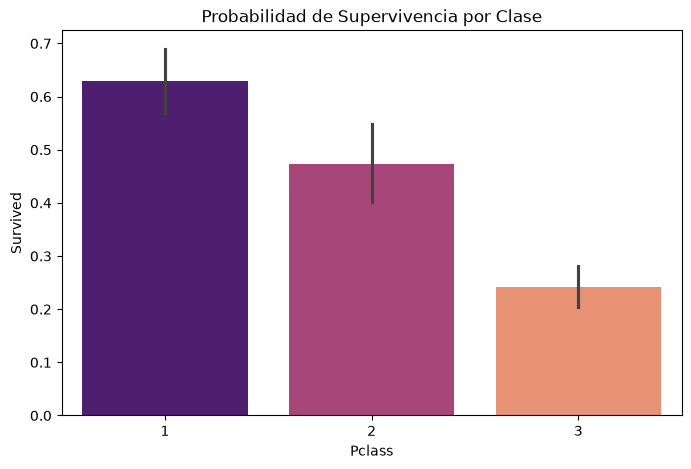

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')
plt.title('Probabilidad de Supervivencia por Clase')
plt.show()

# Distribución de Edades

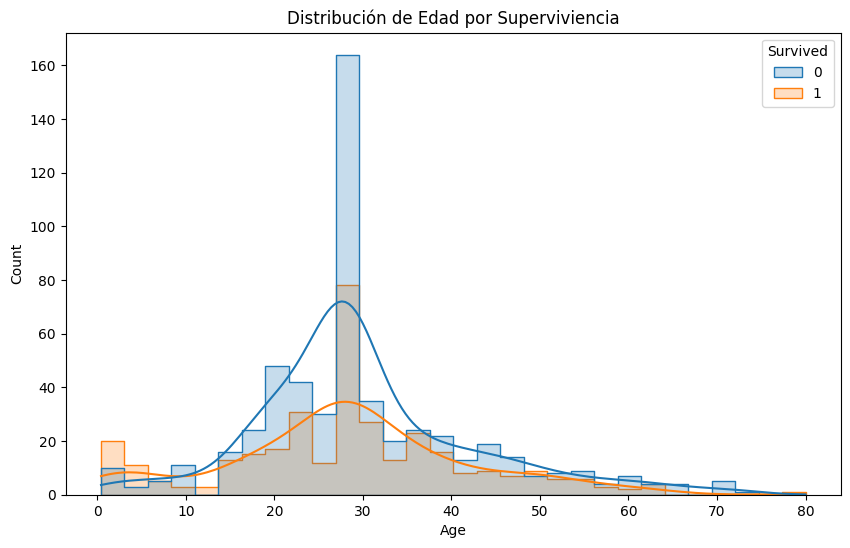

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue= 'Survived', kde=True, element='step')
plt.title('Distribución de Edad por Superviviencia')
plt.show()

In [7]:
df['Sex'] = df['Sex'].map({'male': 0, 'female':1})

df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb')

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Emb_C,Emb_Q,Emb_S
0,0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,1,38.0,1,0,71.2833,True,False,False
2,1,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,0,35.0,0,0,8.0500,False,False,True


In [8]:
df.to_csv('data/titanic_feature.csv', index= False)

print("Datos guardados en data/titanic_feature.csv")

Datos guardados en data/titanic_feature.csv


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('data/titanic_feature.csv')

x = df.drop('Survived', axis=1)
y = df['Survived']
